# initiating 

In [2]:
import random
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from os import listdir
import xlrd
import re


In [3]:
def plot(results, title,victim,names):
    fig = plt.figure(dpi=600)
    fig, ax = plt.subplots()
    markers = ['+', 'x', 'o', 's', 'd', 'D', '*',] # Add your desired markers here
    for d in range(len(results)):
        data = results[d]
        x = [item[1] for item in data]
        y = [item[2] for item in data]
        marker_idx = d % len(markers) # Choose marker based on index of the result
        ax.plot(x, y, marker=markers[marker_idx], linewidth=0.5, markersize=6,label=names[d])

    ax.set_xlabel('#' f'Percentage {victim}  removed')
    ax.set_ylabel(r'$|N_{LCC}| / |N| $')
    ax.set_title(f'{title}  ')
    plt.legend()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [4]:
#used in random attack code 
def batch_list_per(lst,per):
    NSize=len(lst)
    # Divide a list into batches based of the percentage specified in the parameter
    batch_size = round(NSize*per) # each patch size is x% of the netweok size 
    num_batches = (len(lst) + batch_size - 1) // batch_size
    batches = [lst[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]
    return batches


#used in targeted attack code 
def cal_batchSize_per(lst,per):
    NSize=len(lst)
    batch_size = round(NSize*per)
    return batch_size

def simple_batching(lst,batch_size): 
    num_batches = (len(lst) + batch_size - 1) // batch_size
    batches = [lst[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]
    return batches



In [5]:
# use to get the size of the LCC and as a break function to stop the function from calculating alternating network's metrics when the LLC disapears  
def LCC(G):
    connected_components = list(nx.connected_components(G))
    if len(connected_components) > 0:
        subG = G.subgraph(max(connected_components, key=len))
        if len(subG.nodes())>1: 
            return subG
        else:
            return None
    else:
        # Handle the case when there are no connected components
        return None


# Read the Networks 

In [6]:
#since  all the folders has the name pattern (./cloud_networks/datacenter_fattree_graph_output/nodes_100_seed_4/edges.xls) 
# only 2 numerical values are the  network size and seed value, findall function will return teh size and seed valuses

def get_netweokSize(pathString):
    pattern= r'\d+'
    numericalVals= re.findall(pattern,pathString)
    return numericalVals[0],numericalVals[1]

In [7]:
#going over all the directories and edges.xls files to create graph 

#function to return all Edges file of a single network modula  
def get_EdgesFiles(networkModel_path):
    network_dircs= listdir(networkModel_path) #for all the directories within a network 
    Edges_files =[]
    
    for network_dirc in network_dircs:
        all_files =[]
        all_files.append(listdir(f'{networkModel_path}/{network_dirc}'))
        for file in all_files:
            for f in file:
                if f == 'edges.xls':
                    Edges_files.append(f'{networkModel_path}/{network_dirc}/{f}')
    return Edges_files

In [8]:
# create grapg from edges xls files each size of networks;

# function returns a list of "name, size, seed" of graph and graph itself(netwrokX object)
def Creaet_graphs(files,Model):
    Networks=[]
    for file in files:
        Edges= []
        G = nx.Graph()
        book = xlrd.open_workbook(file)
        sheet = book.sheet_by_index(0)
        size,Seed= get_netweokSize(file)
        graph_name = Model+', Size '+str(size) +" seed "+ str(Seed)
        for row in range(1,sheet.nrows):
            data = sheet.row_slice(row)
            node1 = int(data[0].value)
            node2 = int(data[1].value)
            Edges.append((node1,node2))
        G.add_edges_from(Edges)
        Networks.append([graph_name,G])

    return Networks
        

In [18]:
def Cloud_networks():
    gen_path='./cloud_networksB'
    models_names = ["Fat_tree", "Layered", "Microservice"] 
    networks_dircs= listdir(gen_path)
    N_path=[]
    Networks=[]
    for N in networks_dircs:
        N_path.append(f'{gen_path}/{N}')

    for i in range(len(models_names)):
        files = get_EdgesFiles(N_path[i])
        Networks.append(Creaet_graphs(files,models_names[i]))
    return Networks
    

In [19]:
# make the unorganized the list returned from the netwroks() function into list of dictionary, dictionary has 2 entry of netwrok name and the associated graph.
def Networks_DictList ():
    Networks= Cloud_networks()
    networks = []
    for Networks_cats in Networks:
        for i in range(len(Networks_cats)):
            network = {}
            network['name'] = Networks_cats[i][0]
            network['graph'] =Networks_cats[i][1]
            networks.append(network)
    return networks

# Random Attacks

## Nodes Random Attacks 

In [20]:
networks = Networks_DictList()
names=[]
for network in networks:
        names.append(network['name'])

def randomN_AttckSim():
    results = []  
    for network in networks:
        G = network['graph'].copy()
        V = list(G.nodes)
        random.shuffle(V)
        batches = batch_list_per(V,0.1)
        result = []
        for b in range(len(batches)):
            G.remove_nodes_from(batches[b])
            largest_component = LCC(G)
            if largest_component:
                Assortativity = nx.degree_assortativity_coefficient(G)
                ASP = nx.average_shortest_path_length(largest_component)
                eff = round(nx.global_efficiency(largest_component), 12)
                result.append([network['name'],b, len(largest_component)/len(G),Assortativity,ASP,eff])
        results.append(result)
    return results
rndV_results = randomN_AttckSim()



KeyboardInterrupt: 

In [ ]:
table = pd.DataFrame()
nameSS= [];numofBatch=[];LCCT=[];AssortativityT= [];ASPT=[]; effT=[]

for result in  rndV_results:
    for batches in result:
        nameSS.append(batches[0])
        numofBatch.append(batches[1])
        LCCT.append(batches[2])
        AssortativityT.append(batches[3])
        ASPT.append(batches[4])
        effT.append(batches[5])

In [ ]:
table["Networks"]=nameSS
table["batch num / Percentage of nodes removed"]= numofBatch
table["largest_component/N"]=LCCT ;table["Assortativity"]=AssortativityT
table["avrage shortes path"] = ASPT; table["efficiency"] =effT

# table.to_csv('Random_nodesAttcak.csv')

In [299]:
table

,Networks,batch num / Percentage of nodes removed,largest_component/N,Assortativity,avrage shortes path,efficiency
0,"Fat_tree, Size 10000 seed 6673",0,0.890373,-0.360264,5.636272,0.148255
1,"Fat_tree, Size 10000 seed 6673",1,0.820766,-0.353070,5.737455,0.124001
2,"Fat_tree, Size 10000 seed 6673",2,0.750155,-0.347930,5.824207,0.102189
3,"Fat_tree, Size 10000 seed 6673",3,0.668471,-0.350637,5.957098,0.079565
4,"Fat_tree, Size 10000 seed 6673",4,0.578172,-0.325349,6.140770,0.058110
...,...,...,...,...,...,...
85,"Microservice, Size 500 seed 469",4,0.916000,-0.061575,3.338351,0.283928
86,"Microservice, Size 500 seed 469",5,0.910000,0.001927,3.501427,0.270392
87,"Microservice, Size 500 seed 469",6,0.893333,-0.078824,3.672876,0.251709
88,"Microservice, Size 500 seed 469",7,0.890000,-0.047097,4.096782,0.232659


<Figure size 3840x2880 with 0 Axes>

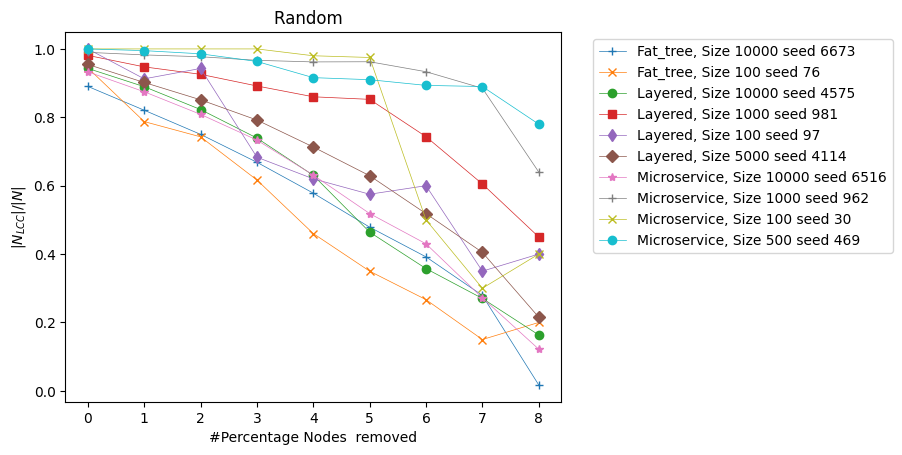

In [301]:
plot(rndV_results, 'Random', 'Nodes',names)

## Edges Random Attacks 

In [ ]:
networks = Networks_DictList()
names=[]
for network in networks:
        names.append(network['name'])

def randomE_AttckSim():
    results = []
    for network in networks:
        G = network['graph'].copy()
        E = list(G.edges)
        random.shuffle(E)
        batches = batch_list_per(E,0.1)
        result = []
        for b in range(len(batches)):
            G.remove_edges_from(batches[b])            
            largest_component = LCC(G)
            if largest_component:
                Assortativity = nx.degree_assortativity_coefficient(G)
                ASP = nx.average_shortest_path_length(largest_component)
                eff = round(nx.global_efficiency(largest_component), 12)
                result.append([network['name'],b, len(largest_component)/len(G),Assortativity,ASP,eff])

        results.append(result)
    return results
rndE_results = randomE_AttckSim()


<Figure size 3840x2880 with 0 Axes>

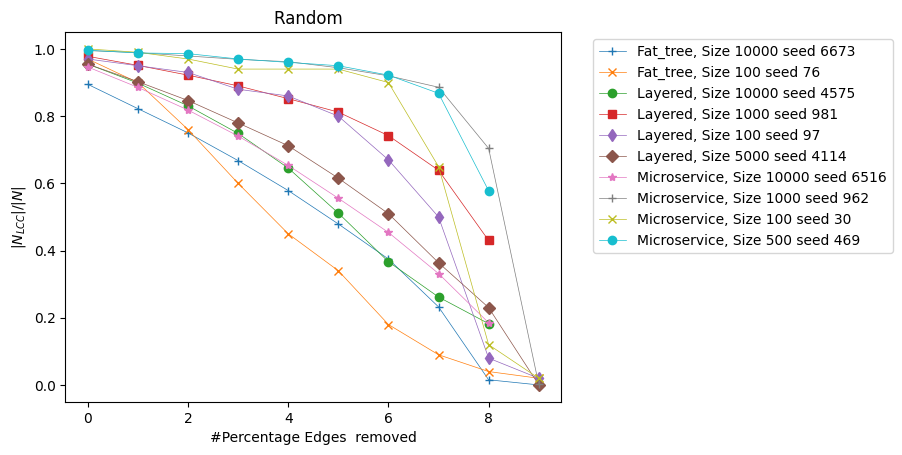

In [311]:
plot(rndE_results, 'Random', 'Edges',names)

In [ ]:
Etable = pd.DataFrame()
ENnames= [];EnumofBatch=[];ELCCT=[];EAssortativityT= [];EASPT=[]; EeffT=[]
for result in  rndE_results:
    for batches in result:
        ENnames.append(batches[0])
        EnumofBatch.append(batches[1])
        ELCCT.append(batches[2])
        EAssortativityT.append(batches[3])
        EASPT.append(batches[4])
        EeffT.append(batches[5])

Etable["Networks"]=ENnames; Etable["batch num / Percentage of Edges  removed"]= EnumofBatch
Etable["largest_component/N"]=ELCCT ;Etable["Assortativity"]=EAssortativityT
Etable["avrage shortes path"] = EASPT
Etable["efficiency"] =EeffT

Etable.to_csv('Random_EdgesAttcak.csv')


In [314]:
Etable

,Networks,batch num / Percentage of Edges removed,largest_component/N,Assortativity,avrage shortes path,efficiency
0,"Fat_tree, Size 10000 seed 6673",0,0.894617,-0.367661,5.677376,0.185380
1,"Fat_tree, Size 10000 seed 6673",1,0.822268,-0.357682,5.856279,0.179857
2,"Fat_tree, Size 10000 seed 6673",2,0.750135,-0.355114,6.077421,0.173474
3,"Fat_tree, Size 10000 seed 6673",3,0.667714,-0.344589,6.355806,0.165915
4,"Fat_tree, Size 10000 seed 6673",4,0.578577,-0.332102,6.749927,0.156541
...,...,...,...,...,...,...
91,"Microservice, Size 500 seed 469",4,0.960000,-0.159005,3.595842,0.304291
92,"Microservice, Size 500 seed 469",5,0.950000,-0.112109,3.988150,0.276585
93,"Microservice, Size 500 seed 469",6,0.922000,-0.127868,4.601500,0.242550
94,"Microservice, Size 500 seed 469",7,0.868000,-0.021865,5.788944,0.197090


# Targeted Attacks

In [21]:
centr = ['Degree','Betweenness']

#return an order list of only the only one CI specified by the paramenter low to hight for recusive method 
def CI_Node_orderd_list2(G,centrality ):
    CI_Dict =centrality(G)
    CI_sortedDict = {k: v for k, v in sorted(CI_Dict.items(), key=lambda item: item[1])}
    CI_sortedList= list(CI_sortedDict.keys())
    return CI_sortedList  


#  return an order edge list of only the only one CI specified by the paramenter low to hight 
def weighted_edges(G, centrality):
    '''return a weighted edges equations from paper 11'''
    W = []

    if centrality == nx.betweenness_centrality:
        CI_Dict = nx.edge_betweenness_centrality(G)
        CI_sortedDict = {k: v for k, v in sorted(CI_Dict.items(), key=lambda item: item[1])}
        for u,v in G.edges():
            W.append([u, v, CI_sortedDict[u,v]] )
    else:
        CI_Dict = centrality(G)
        for u,v in G.edges():
            W.append([u, v, CI_Dict[u]*CI_Dict[v]])
    return sorted(W, key=lambda x: x[2])


In [22]:
def recalculateRecursionGen(network,G,batches,batches_size,centrality,i,results, victim):

    if victim == "Node Attack":
        R = batches[i] # Nodes to be removed...
        G.remove_nodes_from(R)
    else:
        R = [(u,v) for u,v,_ in batches[i]] # edges to be removed...
        G.remove_edges_from(R)

    largest_component = LCC(G)
    if largest_component: #only cal metrics in LCC exist 
        Assortativity = nx.degree_assortativity_coefficient(G) 
        ASP = nx.average_shortest_path_length(largest_component)
        eff = round(nx.global_efficiency(largest_component), 12)
        results.append([network['name'],len(results)+1, len(largest_component)/len(G),Assortativity,ASP,eff])       

    i-=1
    if victim == "Node Attack":
        Ranked_lists = CI_Node_orderd_list2(G,centrality)
    else:    
        Ranked_lists = weighted_edges(G,centrality) 
    
    neWbatches = simple_batching(Ranked_lists,batches_size)
    if  i<=0  : return results
    else: return recalculateRecursionGen(network,G, neWbatches,batches_size,centrality, i ,results,victim)

## Nodes Targeted Attacks 

In [23]:
networks = Networks_DictList()
names=[]
for network in networks:
        names.append(network['name'])
        
def simulationREC(centrality,per):
    results = []  
    for network in networks:
        G = network['graph'].copy()
        Ranked_lists = CI_Node_orderd_list2(G,centrality) 
        batches_size= cal_batchSize_per(Ranked_lists,per)   
        batches = simple_batching(Ranked_lists,batches_size)
        result =recalculateRecursionGen(network,G,batches,batches_size,centrality,len(batches)-1,[],"Node Attack")
        results.append(result)

    return results

c:\Users\fayoy\AppData\Local\Programs\Python\Python313\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


<Figure size 3840x2880 with 0 Axes>

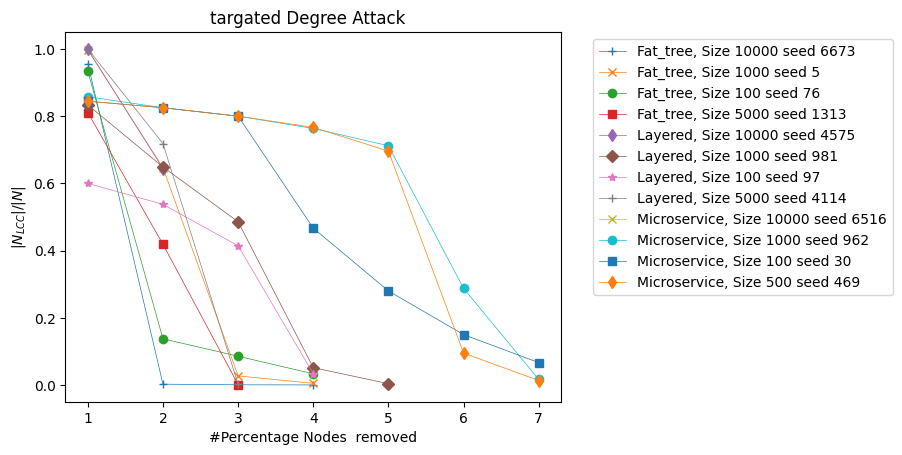

c:\Users\fayoy\AppData\Local\Programs\Python\Python313\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


<Figure size 3840x2880 with 0 Axes>

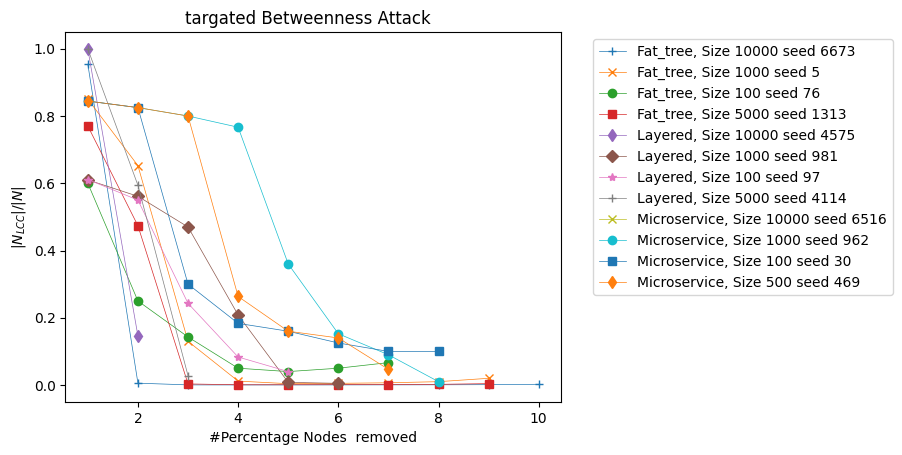

In [24]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
for i in range(len(centralities)):
    
    TA_results = simulationREC(centralities[i],0.1)
    plot(TA_results, f'targated {centr[i]} Attack', 'Nodes',names)
    TTable = pd.DataFrame()
    TnameSS= []
    TLCC=[]
    TnumofBatch=[]
    TAssortativity= []
    T_ASP=[]; T_eff=[]
    for result in  TA_results:
        for batches in result:
            TnameSS.append(batches[0])
            TnumofBatch.append(batches[1])
            TLCC.append(batches[2])
            TAssortativity.append(batches[3])
            T_ASP.append(batches[4])
            T_eff.append(batches[5])

    TTable["Networks"]=TnameSS
    TTable["batch num / Percentage of nodes removed"]= TnumofBatch
    TTable["largest_component/N"]=TLCC; TTable["Assortativity"]=TAssortativity
    TTable["avrage shortes path"]=T_ASP; TTable["efficiency"]=T_eff
    TTable.to_csv(f'Targated {centr[i]}_nodesAttcak.csv')
    TTable

## Edges Targeted Attacks 

In [25]:
networks = Networks_DictList()
names=[]
for network in networks:
    names.append(network['name'])
        
def E_simulationREC(centrality,per):
    results = []  
    for network in networks:
        G = network['graph'].copy()
        Ranked_lists = weighted_edges(G,centrality) 
        batches_size= cal_batchSize_per(Ranked_lists,per)   
        batches = simple_batching(Ranked_lists,batches_size)
        result =recalculateRecursionGen(network,G,batches,batches_size,centrality,len(batches)-1,[],"edge attck")
        results.append(result)

    return results

<Figure size 3840x2880 with 0 Axes>

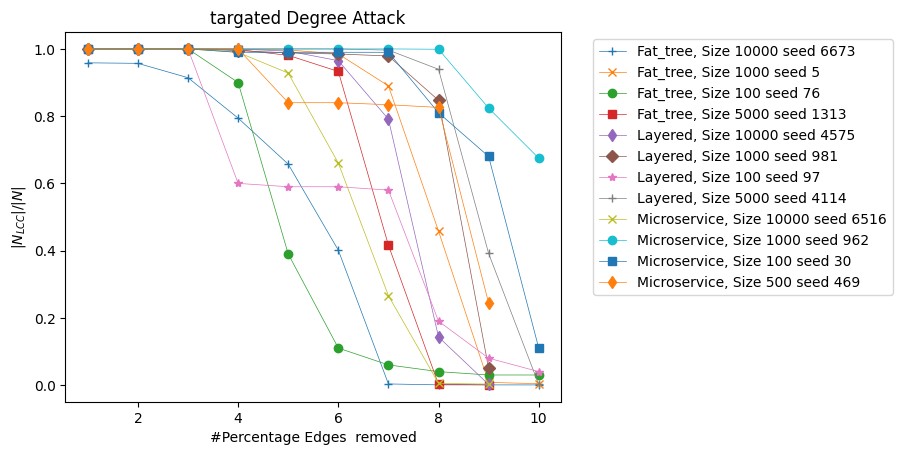

<Figure size 3840x2880 with 0 Axes>

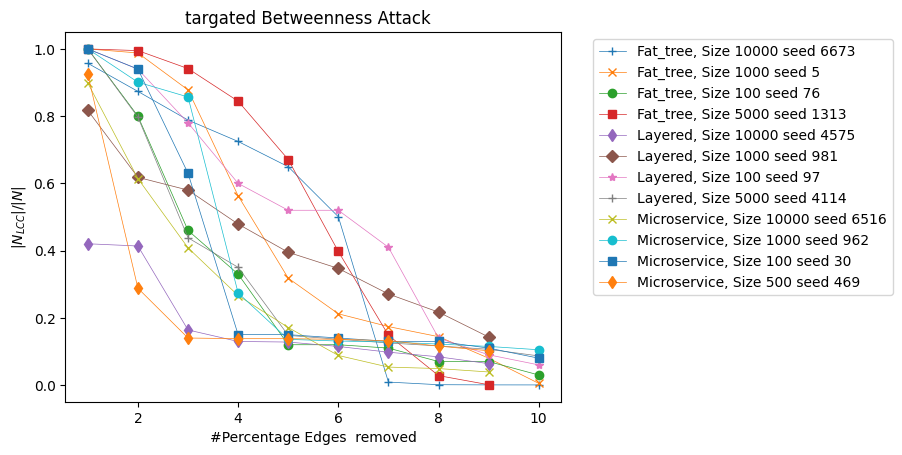

In [26]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
for i in range(len(centralities)):

    ETA_results = E_simulationREC(centralities[i],0.1)
    plot(ETA_results, f'targated {centr[i]} Attack', 'Edges',names)
    
    ETTable = pd.DataFrame()
    ETnameSS= []
    ETLCC=[]
    ETnumofBatch=[]
    ETAssortativity= []
    ET_ASP=[]; ET_eff=[]
    for result in  ETA_results:
        for batches in result:
            ETnameSS.append(batches[0])
            ETnumofBatch.append(batches[1])
            ETLCC.append(batches[2])
            ETAssortativity.append(batches[3])
            ET_ASP.append(batches[4])
            ET_eff.append(batches[5])

    ETTable["Networks"]=ETnameSS
    ETTable["batch num / Percentage of nodes removed"]= ETnumofBatch
    ETTable["largest_component/N"]=ETLCC; ETTable["Assortativity"]=ETAssortativity
    ETTable["avrage shortes path"]=ET_ASP; ETTable["efficiency"]=ET_eff

    ETTable.to_csv(f'Targated {centr[i]}_EdgeAttcak.csv')

